# 01 · Data Loading & Exploratory Analysis
Fetches D2 and 5-HT2A bioactivity data from ChEMBL, curates structures,
computes Morgan fingerprints and Murcko scaffolds, and saves `data.pkl`
for downstream notebooks.

**Output:** `data.pkl`

In [3]:
import sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '.')
from utils import (fetch_curate, get_fp, get_scaffold, SEED, N_FP)
from tqdm import tqdm
tqdm.pandas()

np.random.seed(SEED)
print("Imports OK.")

Imports OK.


## 1. Fetch & curate from ChEMBL
Targets: D2 (`CHEMBL217`) and 5-HT2A (`CHEMBL224`).

In [4]:
# ── Extension hook: add receptor pairs here ───────────────────────────────────
TARGETS = {
    'D2':    'CHEMBL217',
    '5HT2A': 'CHEMBL224',
    # 'H1':  'CHEMBL231',   # uncomment to extend
}

# ── Assay type filter ─────────────────────────────────────────────────────────
# Ki only: equilibrium binding constant — the same physical quantity at both
# receptors. IC50/EC50/Potency/AC50 are assay-format-dependent and introduce
# systematic offsets that corrupt ΔpChEMBL (Kalliokoski et al. PLOS ONE 2013).
# For selectivity modelling where we subtract two pChEMBL values, mixing assay
# types is equivalent to adding lab-specific noise to the target variable.
#
# Switch back to ALL_ASSAY_TYPES below if you want to compare Ki-only vs mixed.
KI_ONLY       = ['Ki']
ALL_ASSAY_TYPES = ['Ki','IC50']

ASSAY_FILTER = KI_ONLY  # ← change to ALL_ASSAY_TYPES to replicate original

print(f"Assay filter: {ASSAY_FILTER}")
print("Fetching activity data from ChEMBL...")
datasets = {}
for name, cid in TARGETS.items():
    datasets[name] = fetch_curate(name, cid, assay_types=ASSAY_FILTER)

d2  = datasets['D2']
sht = datasets['5HT2A']

Assay filter: ['Ki']
Fetching activity data from ChEMBL...
  D2 (CHEMBL217): 9,817 unique structures
  5HT2A (CHEMBL224): 5,221 unique structures


## 2. Fingerprints & scaffolds

In [5]:
print("Computing fingerprints and scaffolds...")
for df in [d2, sht]:
    df['fp']       = df['curated_smiles'].progress_apply(get_fp)
    df['scaffold'] = df['curated_smiles'].apply(get_scaffold)
    df.dropna(subset=['fp'], inplace=True)

# Overlap dataset — compounds tested at BOTH receptors
merged = d2.merge(sht, on='curated_smiles', suffixes=('_D2','_5HT2A'))
merged['delta']    = merged['pChEMBL_5HT2A'] - merged['pChEMBL_D2']
merged['fp']       = merged['curated_smiles'].progress_apply(get_fp)
merged['scaffold'] = merged['curated_smiles'].apply(get_scaffold)
merged.dropna(subset=['fp'], inplace=True)

# Raw fingerprint arrays
X_d2  = np.stack(d2['fp'].values)
X_sht = np.stack(sht['fp'].values)
X_ov  = np.stack(merged['fp'].values)

print(f"D2:      {len(d2):,} unique structures")
print(f"5HT2A:   {len(sht):,} unique structures")
print(f"Overlap: {len(merged):,} compounds tested at both receptors")
print(f"Atypical (5HT2A > D2): {(merged['delta'] > 0).mean()*100:.1f}% of overlap")

Computing fingerprints and scaffolds...


100%|██████████| 2715/2715 [00:00<00:00, 6911.00it/s]


D2:      9,817 unique structures
5HT2A:   5,221 unique structures
Overlap: 2,715 compounds tested at both receptors
Atypical (5HT2A > D2): 66.4% of overlap


## 3. Exploratory data analysis

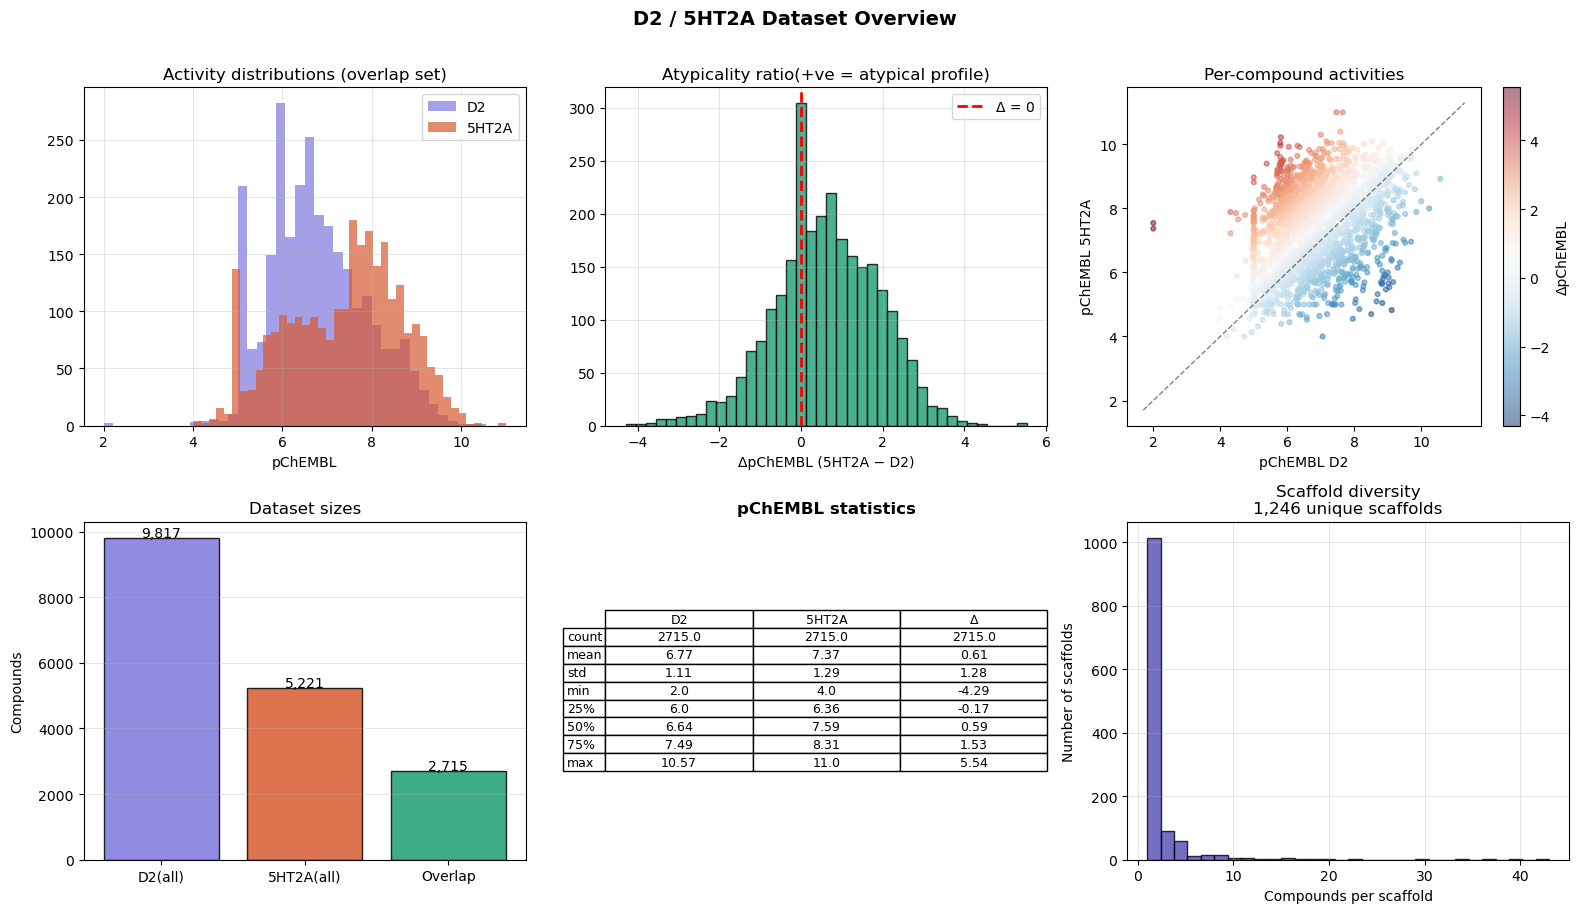

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 3A. Activity distributions
axes[0,0].hist(merged['pChEMBL_D2'],    bins=40, alpha=0.7, color='#7F77DD', label='D2')
axes[0,0].hist(merged['pChEMBL_5HT2A'], bins=40, alpha=0.7, color='#D85A30', label='5HT2A')
axes[0,0].set(xlabel='pChEMBL', title='Activity distributions (overlap set)')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# 3B. Atypicality ratio
axes[0,1].hist(merged['delta'], bins=40, color='#1D9E75', edgecolor='black', alpha=0.8)
axes[0,1].axvline(0, color='red', lw=2, linestyle='--', label='Δ = 0')
axes[0,1].set(xlabel='ΔpChEMBL (5HT2A − D2)',title='Atypicality ratio(+ve = atypical profile)')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# 3C. D2 vs 5HT2A scatter
sc = axes[0,2].scatter(merged['pChEMBL_D2'], merged['pChEMBL_5HT2A'],
                        c=merged['delta'], cmap='RdBu_r', s=12, alpha=0.5)
lo = min(merged['pChEMBL_D2'].min(), merged['pChEMBL_5HT2A'].min()) - 0.3
hi = max(merged['pChEMBL_D2'].max(), merged['pChEMBL_5HT2A'].max()) + 0.3
axes[0,2].plot([lo,hi],[lo,hi],'k--',lw=1,alpha=0.5)
axes[0,2].set(xlabel='pChEMBL D2', ylabel='pChEMBL 5HT2A',
              title='Per-compound activities')
plt.colorbar(sc, ax=axes[0,2], label='ΔpChEMBL')

# 3D. pChEMBL by assay type
for name, df_r, ax in [(('D2', d2, axes[1,0])), ('5HT2A', sht, axes[1,1])]:
    pass  # placeholder — add assay breakdown if standard_type retained

# 3D. Dataset sizes
sizes = {'D2(all)': len(d2), '5HT2A(all)': len(sht),
         'Overlap': len(merged)}
axes[1,0].bar(sizes.keys(), sizes.values(),
              color=['#7F77DD','#D85A30','#1D9E75'], alpha=0.85, edgecolor='black')
for k, v in zip(sizes.keys(), sizes.values()):
    axes[1,0].text(list(sizes.keys()).index(k), v+30, f'{v:,}', ha='center', fontsize=10)
axes[1,0].set(title='Dataset sizes', ylabel='Compounds')
axes[1,0].grid(alpha=0.3, axis='y')

# 3E. pChEMBL statistics table
stats = merged[['pChEMBL_D2','pChEMBL_5HT2A','delta']].describe().round(2)
axes[1,1].axis('off')
tbl = axes[1,1].table(cellText=stats.values, rowLabels=stats.index,
                       colLabels=['D2','5HT2A','Δ'],
                       loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
axes[1,1].set_title('pChEMBL statistics', fontweight='bold')

# 3F. Scaffold diversity
sc_counts = merged['scaffold'].value_counts()
axes[1,2].hist(sc_counts.values, bins=30, color='#534AB7', edgecolor='black', alpha=0.8)
axes[1,2].set(xlabel='Compounds per scaffold', ylabel='Number of scaffolds',
              title=f'Scaffold diversity\n{len(sc_counts):,} unique scaffolds')
axes[1,2].grid(alpha=0.3)

plt.suptitle('D2 / 5HT2A Dataset Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_01_eda.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Scaffold-stratified split

Computed once and saved to `data.pkl`. All downstream notebooks load these indices — never recompute. Ensures A / B / C see identical train / val / test compounds.

In [7]:
import numpy as np

def three_way_scaffold_split(df, train_frac=0.70, val_frac=0.15, seed=SEED):
    rng       = np.random.RandomState(seed)
    scaffolds = df['scaffold'].values
    unique_sc = list(set(scaffolds))
    rng.shuffle(unique_sc)
    n      = len(df)
    n_val  = int(n * val_frac)
    n_test = int(n * (1 - train_frac - val_frac))
    val_sc, test_sc = set(), set()
    n_va, n_te = 0, 0
    for sc in unique_sc:
        cnt = (scaffolds == sc).sum()
        if n_te < n_test:
            test_sc.add(sc); n_te += cnt
        elif n_va < n_val:
            val_sc.add(sc);  n_va += cnt
    te = np.where(np.isin(scaffolds, list(test_sc)))[0]
    va = np.where(np.isin(scaffolds, list(val_sc)))[0]
    tr = np.where(~np.isin(scaffolds, list(test_sc | val_sc)))[0]
    return tr, va, te

tr_ov, va_ov, te_ov = three_way_scaffold_split(merged)
tr_d2, va_d2, te_d2 = three_way_scaffold_split(d2)
tr_st, va_st, te_st = three_way_scaffold_split(sht)

print("Scaffold-stratified 70 / 15 / 15 splits:")
print(f"  Overlap train={len(tr_ov):,}  val={len(va_ov):,}  test={len(te_ov):,}")
print(f"  D2      train={len(tr_d2):,}  val={len(va_d2):,}  test={len(te_d2):,}")
print(f"  5HT2A   train={len(tr_st):,}  val={len(va_st):,}  test={len(te_st):,}")

Scaffold-stratified 70 / 15 / 15 splits:
  Overlap train=1,901  val=407  test=407
  D2      train=6,864  val=1,474  test=1,479
  5HT2A   train=3,617  val=798  test=806


## 6. Save

In [8]:
data = {
    'd2':     d2,
    'sht':    sht,
    'merged': merged,
    'X_d2':   X_d2,
    'X_sht':  X_sht,
    'X_ov':   X_ov,
    'splits': {
        'tr_ov': tr_ov, 'va_ov': va_ov, 'te_ov': te_ov,
        'tr_d2': tr_d2, 'va_d2': va_d2, 'te_d2': te_d2,
        'tr_sht': tr_st, 'va_sht': va_st, 'te_sht': te_st,
    },
    'seed': SEED,
}

with open('data.pkl', 'wb') as f:
    pickle.dump(data, f)

print("Saved: data.pkl")
print(f"  Keys: {list(data.keys())}")
print(f"  X shapes — D2: {X_d2.shape}  5HT2A: {X_sht.shape}  Overlap: {X_ov.shape}")
print(f"  Splits: {list(data['splits'].keys())}")

Saved: data.pkl
  Keys: ['d2', 'sht', 'merged', 'X_d2', 'X_sht', 'X_ov', 'splits', 'seed']
  X shapes — D2: (9817, 2048)  5HT2A: (5221, 2048)  Overlap: (2715, 2048)
  Splits: ['tr_ov', 'va_ov', 'te_ov', 'tr_d2', 'va_d2', 'te_d2', 'tr_sht', 'va_sht', 'te_sht']
